In [ ]:
#Executar apenas a primeira vez
#!pip install -U ydata-profiling

In [ ]:
#imports
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, uniform
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import keras
from sklearn.utils import class_weight
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import layers, regularizers

In [ ]:
df = pd.read_csv('./treino.csv', encoding='latin1')

C:\Users\izzuz\AppData\Local\Temp\ipykernel_25304\1289307098.py:1: DtypeWarning: Columns (36,38,44,60,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./treino.csv', encoding='latin1')


In [ ]:
#Função de apoio
def cast_to_str(X):
    return pd.DataFrame(X).astype(str).replace('nan', 'ignorado')

In [ ]:
# 1. Definir a lista final de preditores (incluindo o alvo ltfu para a análise de correlação)
preditores_selecionados = [
    'idade_anos','CS_SEXO','CS_GESTANT','CS_RACA','CS_ESCOL_N',
    'SG_UF','ID_MN_RESI', 'TRATAMENTO', 'POP_LIBER', 'POP_RUA',
    'POP_SAUDE', 'POP_IMIG', 'FORMA', 'AGRAVALCOO', 'AGRAVDIABE',
    'AGRAVDOENC', 'AGRAVOUTRA', 'HIV', 'DT_INIC_TR', 'SG_UF_2',
    'ID_MUNIC_2', 'TRATSUP_AT', 'TRANSF', 'MUN_TRANSF', 'ltfu'
]

In [ ]:
# 2. Criar o DataFrame filtrado
df_projeto = df[preditores_selecionados].copy()

In [ ]:
# 3. Separar preditores (X) e alvo (y)
X = df_projeto.drop('ltfu', axis=1)
y = df_projeto['ltfu']

In [ ]:
#Separação das colunas
colunas_disponiveis = X.columns.tolist()

num_features = [c for c in ['idade_anos', 'NU_CONTATO'] if c in colunas_disponiveis]
cat_features = [c for c in [
    'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'SG_UF', 'TRATAMENTO',
    'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'FORMA',
    'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'HIV',
    'SG_UF_2', 'TRATSUP_AT', 'TRANSF'
] if c in colunas_disponiveis]
ordinal_features = [c for c in ['CS_ESCOL_N'] if c in colunas_disponiveis]

In [ ]:
# 4. Gerar X_train_sample (com as 24 colunas preditoras)
# Usando a mesma semente (random_state=12)
X_train_sample = X.sample(n=20000, random_state=12) if len(X) > 20000 else X

In [ ]:
# 3. Construção dos Transformadores
num_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=12)),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('to_str', FunctionTransformer(cast_to_str, feature_names_out='one-to-one')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Integrador de Colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('ord', Pipeline(steps=[
            ('to_str', FunctionTransformer(cast_to_str, feature_names_out='one-to-one')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), ordinal_features)
    ])

# 5. Pipeline Final (Baseline)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=12, max_iter=5000, tol=0.01, class_weight='balanced'))
])

# 6. Execução do Treinamento
print("Iniciando treinamento do baseline_pipeline...")
try:
    baseline_pipeline.fit(X, y)
    print("✅ Sucesso! Modelo treinado e baseline_pipeline definido.")
except Exception as e:
    print(f"❌ Erro detectado: {e}")

Iniciando treinamento do baseline_pipeline...
✅ Sucesso! Modelo treinado e baseline_pipeline definido.


In [ ]:
# Importar um modelo salvo com joblib (ex: baseline_pipeline)
#baseline_pipeline = joblib.load('baseline_pipeline_v1_peso.pkl')

In [ ]:
# 1. Extrair o preprocessor do baseline_pipeline
# O preprocessor é o primeiro passo do pipeline (índice 0)
preprocessor = baseline_pipeline.named_steps['preprocessor']

# 2. Aplicar as transformações aos dados de treino (X)
X_transformed = preprocessor.transform(X)

# 3. Obter os nomes das colunas após as transformações
# Isso é crucial para criar um DataFrame legível
feature_names_transformed = preprocessor.get_feature_names_out()

# 4. Criar um novo DataFrame com os dados transformados
X_train_transformed_df = pd.DataFrame(X_transformed, columns=feature_names_transformed)

print("DataFrame de treino transformado (X_train_transformed_df) criado com sucesso.")
print("Formato do DataFrame transformado:", X_train_transformed_df.shape)
print("Primeiras 5 linhas do DataFrame transformado:")
print(X_train_transformed_df.head())

DataFrame de treino transformado (X_train_transformed_df) criado com sucesso.
Formato do DataFrame transformado: (562632, 129)
Primeiras 5 linhas do DataFrame transformado:
   num__idade_anos  cat__CS_SEXO_F  cat__CS_SEXO_I  cat__CS_SEXO_M  \
0        -0.583333             0.0             0.0             1.0   
1         0.416667             0.0             0.0             1.0   
2         0.250000             0.0             0.0             1.0   
3        -0.541667             0.0             0.0             1.0   
4        -0.250000             0.0             0.0             1.0   

   cat__CS_GESTANT_5  cat__CS_GESTANT_6  cat__CS_GESTANT_9  cat__CS_RACA_0.0  \
0                0.0                1.0                0.0               0.0   
1                0.0                1.0                0.0               0.0   
2                0.0                1.0                0.0               0.0   
3                0.0                1.0                0.0               1.0   
4     

In [ ]:
#Treinamento com RandomizedSearchCV descartado por possuir métricas piores

In [ ]:
# 'baseline_pipeline' é o pipeline completo já definido contendo o preprocessor e o LogisticRegression.
# 'X' e 'y' são seus dados de treino, e 'X_test1', 'y_test1' são seus dados de teste.

# 1. Definir as distribuições de parâmetros para o RandomizedSearchCV
# Os parâmetros são acessados com o nome da etapa do pipeline (classifier) seguido de '__' e o nome do parâmetro.
# param_distributions = {
#     'classifier__C': loguniform(1e-3, 1e2),  # C: Inverso da força de regularização (explora uma ampla gama log-uniforme)
#     'classifier__l1_ratio': np.arange(0.1, 1.0, 0.1), # l1_ratio: Proporção L1 para Elastic-Net (de 0.1 a 0.9, com 0.1 de passo)
#     'classifier__solver': ['saga'],          # 'saga' é o único solver que suporta a penalidade elasticnet
#     'classifier__penalty': ['elasticnet']    # Usar penalidade elasticnet
# }

# 2. Definir a estratégia de validação cruzada
# StratifiedKFold é recomendado para lidar com datasets desbalanceados, garantindo que as proporções das classes sejam mantidas em cada fold.
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

# 3. Inicializar o RandomizedSearchCV
# random_search_baseline = RandomizedSearchCV(
#     estimator=baseline_pipeline, # O pipeline completo a ser tunado
#     param_distributions=param_distributions,
#     n_iter=50,  # Número de combinações de parâmetros a serem amostradas (o mesmo do seu exemplo)
#     cv=cv_strategy,
#     scoring='recall',  # Métrica de avaliação: Recall (foco no seu objetivo)
#     n_jobs=-1,  # Usar todos os núcleos da CPU disponíveis para processamento paralelo
#     random_state=12, # Semente para reprodutibilidade dos resultados
#     verbose=2 # Exibir o progresso detalhado durante a busca
# )

# print("Iniciando tunagem do baseline_pipeline com RandomizedSearchCV...")

# 4. Ajustar o RandomizedSearchCV aos dados de treino
# O pipeline interno irá lidar automaticamente com o pré-processamento dos dados.
# random_search_baseline.fit(X, y)

# print("Finalizado tunagem do baseline_pipeline com RandomizedSearchCV...")

Iniciando tunagem do baseline_pipeline com RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Finalizado tunagem do baseline_pipeline com RandomizedSearchCV...


In [ ]:
# Salvar o modelo
# joblib.dump(baseline_pipeline, 'baseline_pipeline_v1_peso.pkl')
# print("✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_v1_peso.pkl'")

# joblib.dump(random_search_baseline, 'baseline_tunado_RSCV_v1_peso.pkl')
# print("✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_tunado_RSCV_v1_peso.pkl'")

✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_v1_peso.pkl'
✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_tunado_RSCV_v1_peso.pkl'


In [ ]:
# Importar um modelo salvo com joblib (ex: baseline_tunado_RSCV_v1)
# random_search_baseline = joblib.load('baseline_tunado_RSCV_v1_peso.pkl')

In [ ]:
# 1. Carregar o arquivo de teste (certifique-se de que o caminho está correto)
df_teste1 = pd.read_csv('./teste1.csv', encoding='latin1')

# 2. Separar X e y do teste usando os mesmos preditores do treino
# Importante: usamos a lista 'preditores_selecionados' que definimos antes
X_test1 = df_teste1.drop('ltfu', axis=1)
y_test1 = df_teste1['ltfu']

print("Dados de teste (X_test1, y_test1) carregados e separados com sucesso.")

Dados de teste (X_test1, y_test1) carregados e separados com sucesso.


In [ ]:
print("--- Avaliando o Pipeline Baseline Inicial (sem RandomizedSearchCV) ---")
y_pred_baseline_initial = baseline_pipeline.predict(X_test1)
print(classification_report(y_test1, y_pred_baseline_initial))

# Para uma comparação mais direta do Recall
recall_baseline_initial = classification_report(y_test1, y_pred_baseline_initial, output_dict=True)['1']['recall']

print(f"\n--- Comparativo de Recall (Classe 1 - Abandono) ---")
print(f"Recall do Pipeline Baseline Inicial: {recall_baseline_initial:.4f}")

--- Avaliando o Pipeline Baseline Inicial (sem RandomizedSearchCV) ---
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       354
           1       0.64      0.86      0.73       277

    accuracy                           0.72       631
   macro avg       0.74      0.74      0.72       631
weighted avg       0.76      0.72      0.72       631


--- Avaliando o Melhor Modelo do RandomizedSearchCV (Tuned Baseline) ---
              precision    recall  f1-score   support

           0       0.84      0.61      0.71       354
           1       0.63      0.85      0.73       277

    accuracy                           0.72       631
   macro avg       0.74      0.73      0.72       631
weighted avg       0.75      0.72      0.72       631


--- Comparativo de Recall (Classe 1 - Abandono) ---
Recall do Pipeline Baseline Inicial: 0.8628
Recall do Modelo Tunado (RandomizedSearchCV): 0.8520


--- Relatório de Classificação (Teste 1) ---
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       354
           1       0.64      0.86      0.73       277

    accuracy                           0.72       631
   macro avg       0.74      0.74      0.72       631
weighted avg       0.76      0.72      0.72       631

--- Matriz de Confusão ---


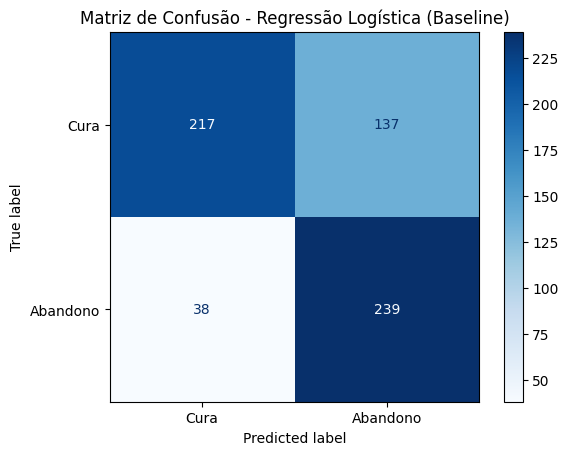

In [ ]:
# 3. Fazer as predições usando o pipeline treinado
y_pred = baseline_pipeline.predict(X_test1)
y_proba = baseline_pipeline.predict_proba(X_test1)[:, 1] # Probabilidade de abandono

# 4. Gerar o Relatório de Métricas
print("--- Relatório de Classificação (Teste 1) ---")
print(classification_report(y_test1, y_pred))

# 5. Visualizar a Matriz de Confusão (Fundamental para o Relatório Científico)
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_test1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cura', 'Abandono'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística (Baseline)')
plt.show()

In [ ]:
# Calcular os pesos de classe
# 'balanced' ajusta os pesos inversamente proporcionais às frequências da classe
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Converter para um dicionário para ser usado pelo Keras
class_weights_dict = dict(enumerate(class_weights))

print("Pesos de classe calculados:", class_weights_dict)

Pesos de classe calculados: {0: 0.6204888635972632, 1: 2.574880553572409}


In [ ]:
# 1. Preparar os dados (Transformar X e X_test1 usando o preprocessor)
# O preprocessor já está definido dentro do baseline_pipeline
X_train_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X)
X_test1_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_test1)

# 2. Definir a Arquitetura da Rede Neural (do primeiro modelo, mais robusto)
robust_model = Sequential([
    layers.Input(shape=(X_train_transformed.shape[1],)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

# 3. Compilar o Modelo (do segundo modelo, com foco em Recall e Adam padrão)
robust_model.compile(
    optimizer='adam', # Adam com learning rate padrão (0.001)
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name='recall')] # Focar no Recall
)

# Callbacks RECALL
early_stop = keras.callbacks.EarlyStopping(
    monitor='recall_val',
    patience=20,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='recall_val',
    factor=0.01,
    patience=5,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

# 4. Treinar a Rede Neural (do segundo modelo, com class_weights)
print("Iniciando o treinamento da Rede Neural Combinada...")
history_combined = robust_model.fit(
    X_train_transformed, y,
    epochs=150, # Manter o número de épocas da segunda rede
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict # Usar os pesos de classe calculados
)
print("Finalizado o treinamento da Rede Neural Combinada...")

Iniciando o treinamento da Rede Neural Combinada...
Epoch 1/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 0.6274 - recall: 0.6694 - val_loss: 0.6114 - val_recall: 0.7692
Epoch 2/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.5829 - recall: 0.6739 - val_loss: 0.5344 - val_recall: 0.5837
Epoch 3/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.5784 - recall: 0.6755 - val_loss: 0.5791 - val_recall: 0.6614
Epoch 4/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.5758 - recall: 0.6712 - val_loss: 0.6034 - val_recall: 0.7454
Epoch 5/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.5747 - recall: 0.6705 - val_loss: 0.6190 - val_recall: 0.7780
Epoch 6/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.5746 - recall: 0.6748 - val_loss: 0.5553 - val_recall: 0.6276
Epoch 7/150
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.5740 - recall: 0.6700 - val_loss: 0.5792 - val_recall: 0.7083
Epoch 8/150
14066/14066 ━━━━━━━━━━━━━━

In [ ]:
# robust_model.save('modelo_redeneural_tuberculose_vFinal_treino1.keras')
# print("✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino1.keras'")

✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino1.keras'


In [ ]:
# robust_model = tf.keras.models.load_model('modelo_redeneural_tuberculose_vFinal_treino1.keras')
# print("✅ Modelo Keras 'modelo_redeneural_tuberculose_vFinal_treino1.keras' carregado com sucesso!")

✅ Modelo Keras 'modelo_redeneural_tuberculose_vFinal_treino1.keras' carregado com sucesso!


In [ ]:
# 5. Avaliação no Teste 1
y_pred_combined = (robust_model.predict(X_test1_transformed) > 0.5).astype(int)

print("\n--- Relatório de Classificação: Rede Neural Combinada ---")
print(classification_report(y_test1, y_pred_combined))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Relatório de Classificação: Rede Neural Combinada ---
              precision    recall  f1-score   support

           0       0.86      0.57      0.68       354
           1       0.62      0.88      0.72       277

    accuracy                           0.71       631
   macro avg       0.74      0.72      0.70       631
weighted avg       0.75      0.71      0.70       631



In [ ]:
# Combinar os dados de treino e teste1
X_combined = pd.concat([X, X_test1], ignore_index=True)
y_combined = pd.concat([y, y_test1], ignore_index=True)

print("Dados de treino e teste1 combinados com sucesso.")
print(f"Formato de X_combined: {X_combined.shape}")
print(f"Formato de y_combined: {y_combined.shape}")

Dados de treino e teste1 combinados com sucesso.
Formato de X_combined: (563263, 100)
Formato de y_combined: (563263,)


In [ ]:
# Retreinar o Baseline Pipeline com os dados combinados
print("\nRetreinando o baseline_pipeline com os dados combinados...")
try:
    baseline_pipeline.fit(X_combined, y_combined)
    print("✅ Sucesso! Baseline pipeline retreinado com dados combinados.")
except Exception as e:
    print(f"❌ Erro ao retreinar baseline_pipeline: {e}")


Retreinando o baseline_pipeline com os dados combinados...
✅ Sucesso! Baseline pipeline retreinado com dados combinados.


In [ ]:
# 1. Carregar o arquivo de teste final (teste2.csv)
df_teste2 = pd.read_csv('./teste2.csv', encoding='latin1')

# 2. Separar os preditores (X_test2) e o alvo (y_test2)
# Usamos 'ltfu' como a coluna alvo, como feito anteriormente.
X_test2 = df_teste2.drop('ltfu', axis=1)
y_test2 = df_teste2['ltfu']

print("Dados de teste final (teste2.csv) carregados e separados com sucesso.")
print(f"Formato de X_test2: {X_test2.shape}")
print(f"Formato de y_test2: {y_test2.shape}")

Dados de teste final (teste2.csv) carregados e separados com sucesso.
Formato de X_test2: (631, 100)
Formato de y_test2: (631,)


In [ ]:
y_pred2 = (baseline_pipeline.predict(X_test2) > 0.5).astype(int)

print("--- RESULTADO FINAL DEFINITIVO baseline (TESTE 2) ---")
print(classification_report(y_test2, y_pred2))

--- RESULTADO FINAL DEFINITIVO baseline (TESTE 2) ---
              precision    recall  f1-score   support

           0       0.74      0.51      0.60       193
           1       0.81      0.92      0.86       438

    accuracy                           0.80       631
   macro avg       0.78      0.72      0.73       631
weighted avg       0.79      0.80      0.78       631

--- RESULTADO FINAL DEFINITIVO tunado (TESTE 2) ---
              precision    recall  f1-score   support

           0       0.73      0.50      0.60       193
           1       0.81      0.92      0.86       438

    accuracy                           0.79       631
   macro avg       0.77      0.71      0.73       631
weighted avg       0.79      0.79      0.78       631



In [ ]:
# Salvar o modelo
# joblib.dump(baseline_pipeline, 'baseline_pipeline_treino2.pkl')
# print("✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_treino2.pkl'")

# joblib.dump(random_search_baseline, 'baseline_tunado_treino2.pkl')
# print("✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_tunado_treino2.pkl'")

✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_treino2.pkl'
✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_tunado_treino2.pkl'


In [ ]:
# 4. Calcular novos pesos de classe para os dados combinados
class_weights_combined = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_combined),
    y=y_combined
)
class_weights_dict_combined = dict(enumerate(class_weights_combined))

In [ ]:
# Preparar os dados (Transformar X combinado e X_test2 usando o preprocessor)
# Preparar dados para a Rede Neural (transformar X_combined)
X_combined_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_combined)
X_test2_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_test2)

In [ ]:
# Definir a Arquitetura da Rede Neural
robust_model_retrained = Sequential([
    layers.Input(shape=(X_combined_transformed.shape[1],)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

# Compilar o Modelo (do segundo modelo, com foco em Recall e Adam padrão)
robust_model_retrained.compile(
    optimizer='adam', # Adam com learning rate padrão (0.001)
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name='recall')] # Focar no Recall
)

# Callbacks RECALL
early_stop = keras.callbacks.EarlyStopping(
    monitor='recall_val',
    patience=20,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='recall_val',
    factor=0.01,
    patience=5,
    min_lr=1e-8,
    verbose=1,
    mode='max'
)

# 4. Treinar a Rede Neural (do segundo modelo, com class_weights)
print("Iniciando o retreinamento da Rede Neural Combinada...")
history_combined_retrained = robust_model_retrained.fit(
    X_combined_transformed, y_combined,
    epochs=150, # Manter o número de épocas da segunda rede
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict_combined # Usar os pesos de classe calculados
)
print("Finalizado o retreinamento da Rede Neural Combinada...")

Iniciando o retreinamento da Rede Neural Combinada...
Epoch 1/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.6258 - recall: 0.6726 - val_loss: 0.6480 - val_recall: 0.8110
Epoch 2/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.5820 - recall: 0.6735 - val_loss: 0.5904 - val_recall: 0.6950
Epoch 3/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.5783 - recall: 0.6692 - val_loss: 0.6106 - val_recall: 0.7571
Epoch 4/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.5763 - recall: 0.6722 - val_loss: 0.5926 - val_recall: 0.7070
Epoch 5/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.5748 - recall: 0.6754 - val_loss: 0.6059 - val_recall: 0.7127
Epoch 6/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.5741 - recall: 0.6719 - val_loss: 0.6604 - val_recall: 0.7975
Epoch 7/150
14082/14082 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 0.5738 - recall: 0.6712 - val_loss: 0.6088 - val_recall: 0.7348
Epoch 8/150
14082/14082 ━━━━━━━━━━━━

In [ ]:
y_pred_retrained = (robust_model_retrained.predict(X_test2_transformed) > 0.5).astype(int)

print("\n--- Relatório de Classificação: Rede Neural Combinada ---")
print(classification_report(y_test2, y_pred_retrained))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- Relatório de Classificação: Rede Neural Combinada ---
              precision    recall  f1-score   support

           0       0.72      0.56      0.63       193
           1       0.82      0.90      0.86       438

    accuracy                           0.80       631
   macro avg       0.77      0.73      0.75       631
weighted avg       0.79      0.80      0.79       631



In [ ]:
# robust_model_retrained.save('modelo_redeneural_tuberculose_vFinal_treino2.keras')
# print("✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino2.keras'")

✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino2.keras'


In [ ]:
robust_model = tf.keras.models.load_model('modelo_redeneural_tuberculose_vFinal_treino2.keras')
print("✅ Modelo Keras 'modelo_redeneural_tuberculose_vFinal_treino2.keras' carregado com sucesso!")

✅ Modelo Keras 'modelo_redeneural_tuberculose_vFinal_treino2.keras' carregado com sucesso!


--- Matriz de Confusão ---


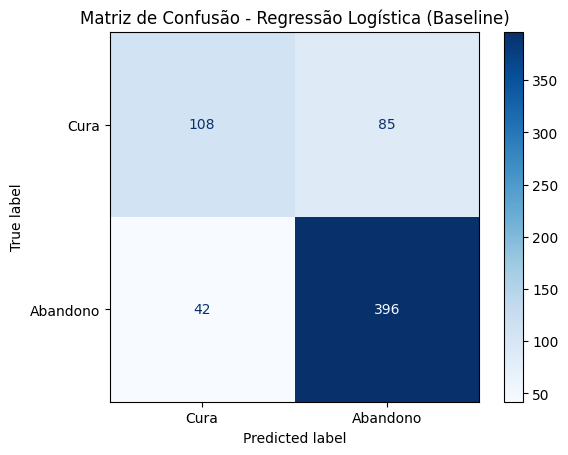

In [ ]:
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_test2, y_pred_retrained)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não abandono', 'Abandono'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

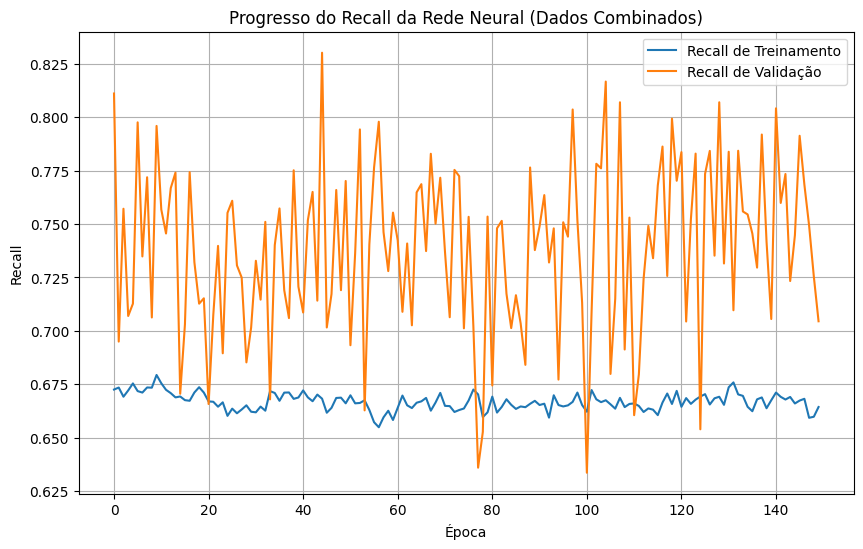

In [ ]:
# Verifica se o objeto history_retrained existe
if 'history_combined_retrained' in locals():
    # Acompanhar o Recall durante o treinamento
    plt.figure(figsize=(10, 6))
    plt.plot(history_combined_retrained.history['recall'], label='Recall de Treinamento')
    plt.plot(history_combined_retrained.history['val_recall'], label='Recall de Validação')
    plt.title('Progresso do Recall da Rede Neural (Dados Combinados)')
    plt.xlabel('Época')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("❌ Erro: O objeto 'history_retrained' não foi encontrado. Certifique-se de executar a célula de treinamento da rede neural com os dados combinados (XLJvj3OPy5Or) antes.")

Gerando o gráfico SHAP para a Rede Neural. Isso pode levar alguns minutos...
❌ Erro ao inicializar DeepExplainer: The layer sequential_1 has never been called and thus has no defined input.. Tentando com o modelo diretamente.
Type of shap_values_raw: <class 'numpy.ndarray'>
Shape of shap_values (if numpy array): (500, 129, 1)
Shape of shap_values after squeezing: (500, 129)
Shape of X_sample_transformed: (500, 129)
Shape of shap_values: (500, 129)
Length of feature_names_transformed: 129


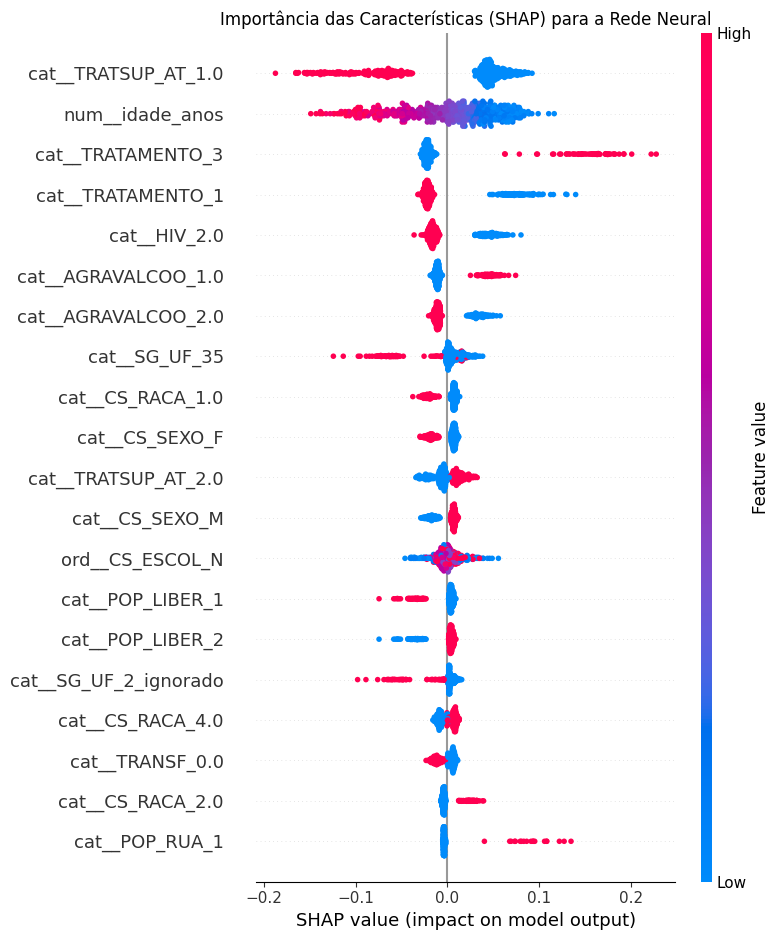

✅ Gráfico SHAP gerado com sucesso!


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Verificar se robust_model_retrained e X_combined_transformed existem
if 'robust_model_retrained' not in locals() or 'X_combined_transformed' not in locals():
    print("❌ Erro: 'robust_model_retrained' ou 'X_combined_transformed' não foram encontrados. Certifique-se de executar a célula de treinamento da rede neural com os dados combinados (XLJvj3OPy5Or) antes.")
else:
    print("Gerando o gráfico SHAP para a Rede Neural. Isso pode levar alguns minutos...")

    # 1. Obter os nomes das colunas após as transformações do baseline_pipeline
    # Isso é crucial para que o gráfico SHAP tenha labels significativas
    feature_names_transformed = baseline_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # 2. Amostrar os dados transformados para acelerar o cálculo SHAP
    if X_combined_transformed.shape[0] > 1000:
        sample_indices = np.random.choice(X_combined_transformed.shape[0], 500, replace=False)
        X_sample_transformed = X_combined_transformed[sample_indices]
    else:
        X_sample_transformed = X_combined_transformed

    # 3. Criar o explainer SHAP para a Rede Neural (DeepExplainer é o mais indicado para Keras)
    # É importante passar os dados de fundo (background data) como um array numpy.
    try:
        explainer = shap.DeepExplainer((robust_model_retrained.input, robust_model_retrained.output), X_sample_transformed)
    except Exception as e:
        print(f"❌ Erro ao inicializar DeepExplainer: {e}. Tentando com o modelo diretamente.")
        explainer = shap.DeepExplainer(robust_model_retrained, X_sample_transformed)

    # 4. Calcular os valores SHAP
    shap_values_raw = explainer.shap_values(X_sample_transformed)

    # --- Debugging shapes ---
    print(f"Type of shap_values_raw: {type(shap_values_raw)}")
    if isinstance(shap_values_raw, list):
        print(f"Length of shap_values_raw list: {len(shap_values_raw)}")
        # Precisamos encontrar o array com o shape correto (num_samples, num_features)
        # Para classificação binária com sigmoid, shap_values geralmente retorna uma lista com um único array.
        # Se o modelo tem uma saída (logits ou probabilidades), geralmente é o primeiro (e único) item.
        if len(shap_values_raw) > 0:
            shap_values = shap_values_raw[0] # Pegamos o primeiro elemento da lista
            print(f"Shape of extracted shap_values: {shap_values.shape}")
        else:
            raise ValueError("shap_values_raw is an empty list.")
    elif isinstance(shap_values_raw, np.ndarray):
        shap_values = shap_values_raw
        print(f"Shape of shap_values (if numpy array): {shap_values.shape}")
    else:
        raise TypeError(f"Unexpected type for shap_values_raw: {type(shap_values_raw)}")

    # Ajuste para remover a dimensão extra se presente, como (500, 129, 1) para (500, 129)
    if shap_values.ndim == 3 and shap_values.shape[2] == 1:
        shap_values = shap_values[:, :, 0]
        print(f"Shape of shap_values after squeezing: {shap_values.shape}")

    print(f"Shape of X_sample_transformed: {X_sample_transformed.shape}")
    print(f"Shape of shap_values: {shap_values.shape}")
    print(f"Length of feature_names_transformed: {len(feature_names_transformed)}")
    # ---

    # Certifique-se de que shap_values tem a forma (num_samples, num_features) para o summary_plot
    if shap_values.shape != X_sample_transformed.shape:
        print("❌ Erro de shape mismatch persistente. SHAP values não possuem o shape esperado para o summary_plot.")
        print("Shape esperado: {}, Shape obtido: {}".format(X_sample_transformed.shape, shap_values.shape))
    else:
        # 5. Gerar o gráfico de importância (Summary Plot)
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample_transformed, feature_names=feature_names_transformed, show=False)
        plt.title('Importância das Características (SHAP) para a Rede Neural')
        plt.tight_layout()
        plt.show()
        print("✅ Gráfico SHAP gerado com sucesso!")